In [38]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

In [19]:
df = pd.read_csv("data.csv", names=["id", "price", "brand", "zip", "region", "title"])
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df.dropna(subset=["price", "zip"], inplace=True)
subset = ['brand']
df.loc[:, subset] = df.loc[:, subset].fillna("Andere Marken")

In [20]:
df

,id,price,brand,zip,region,title
1,1.780674e+09,70.0,Swatch,1230.0,Wien,Swatch Irony Aluminium
2,1.346994e+09,80.0,Andere Marken,1220.0,Wien,Oriosa
3,1.515555e+09,1900.0,TAG Heuer,1180.0,Wien,TAG Heuer Link Calibre 36 El-Primero
4,1.487998e+09,25.0,Andere Marken,1220.0,Wien,Bifora - Armbanduhr Damen
5,7.765301e+08,50.0,Andere Marken,9020.0,Kärnten,Marke Crell Armbanduhr im Chronolgraphen-Lock ...
...,...,...,...,...,...,...
45356,1.990489e+09,725.0,Andere Marken,7522.0,Burgenland,Optima Chronograph Venus 170
45357,1.420515e+09,445.0,Andere Marken,7522.0,Burgenland,Tollet Chronograph Landeron 51
45358,1.309002e+09,499.0,Glashütte,7522.0,Burgenland,Glashütte Spezimatic Uhr GUB Kal. 772 grünes Z...
45359,2.118259e+09,15.0,Esprit,9135.0,Kärnten,Esprit Uhr


In [21]:
c = Counter(" ".join(df["title"]).split())
c.most_common(200)

[('Uhr', 11087),
 ('Armbanduhr', 8783),
 ('-', 5248),
 ('Damenuhr', 3301),
 ('Swatch', 3059),
 ('Damen', 2775),
 ('mit', 2390),
 ('Herren', 2184),
 ('Vintage', 1909),
 ('Herrenuhr', 1666),
 ('Chronograph', 1629),
 ('Lemans', 1249),
 ('Fossil', 1218),
 ('Jacques', 1187),
 ('Automatik', 1125),
 ('Uhren', 1041),
 ('Seiko', 959),
 ('und', 945),
 ('von', 926),
 ('Watch', 920),
 ('NEU', 904),
 ('Michael', 793),
 ('Rolex', 784),
 ('/', 776),
 ('Casio', 760),
 ('Kors', 747),
 ('Automatic', 731),
 ('Quartz', 709),
 ('Diesel', 704),
 ('in', 671),
 ('neu', 662),
 ('&', 650),
 ('Swiss', 643),
 ('Omega', 642),
 ('Armband', 605),
 ('uhr', 587),
 ('Gold', 576),
 ('Handaufzug', 573),
 ('Herrenarmbanduhr', 554),
 ('Esprit', 551),
 ('Quarz', 538),
 ('Tissot', 538),
 ('Chrono', 522),
 ('Citizen', 520),
 ('Armbanduhren', 520),
 ('Neu', 511),
 ('|', 496),
 ('Hilfiger', 491),
 ('Original', 490),
 ('SWATCH', 489),
 ('Edition', 474),
 ('aus', 472),
 ('Tommy', 470),
 ('Daniel', 457),
 ('Damenarmbanduhr', 452),

In [22]:
df["is_damen"] = df["title"].str.contains("damen",case=False)
df["is_herren"] = df["title"].str.contains("herren",case=False)
df["is_new"] = df["title"].str.contains("neu|ungetragen", case=False, regex=True)
df["is_antique"] = df["title"].str.contains("alt|vintage|antil|antique", case=False, regex=True)
df["is_chronograph"] = df["title"].str.contains("chrono", case=False)

In [29]:
X = pd.get_dummies(df.drop(['region', "title", "price"], axis=1), columns=['brand'])
Y = df["price"]
X

,id,zip,is_damen,is_herren,is_new,is_antique,is_chronograph,brand_Adidas,brand_Andere Marken,brand_Armani,...,brand_Seiko,brand_Swarovski,brand_Swatch,brand_TAG Heuer,brand_Thomas Sabo,brand_Tissot,brand_Tommy Hilfiger,brand_Tudor,brand_Zenith,brand_s.Oliver
1,1.780674e+09,1230.0,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
2,1.346994e+09,1220.0,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,1.515555e+09,1180.0,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,1.487998e+09,1220.0,True,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
5,7.765301e+08,9020.0,False,False,True,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45356,1.990489e+09,7522.0,False,False,False,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
45357,1.420515e+09,7522.0,False,False,False,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
45358,1.309002e+09,7522.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
45359,2.118259e+09,9135.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


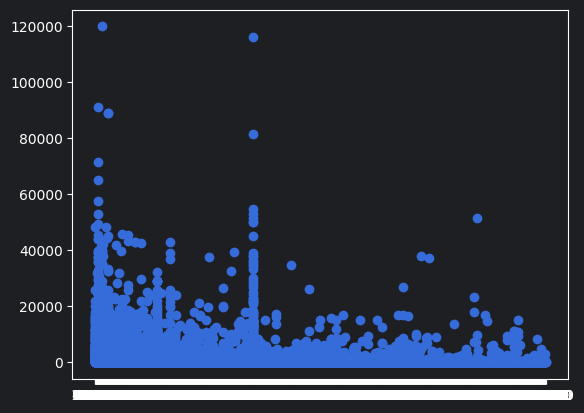

In [30]:
plt.scatter(X["zip"], Y)
plt.show()

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 5. Train Model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# 6. Evaluate
predictions = model.predict(X_test)
print(f"MAE train: {mean_absolute_error(y_train, model.predict(X_train))}")
print(f"MAE test: {mean_absolute_error(y_test, predictions)}")
print(f"RMSE: {root_mean_squared_error(y_test, predictions)}")
print(f"R2: {r2_score(y_test, predictions)}")

MAE train: 174.89754487242874
MAE test: 451.7951754790908
RMSE: 2295.3268086266926
R2: 0.3754972037058413


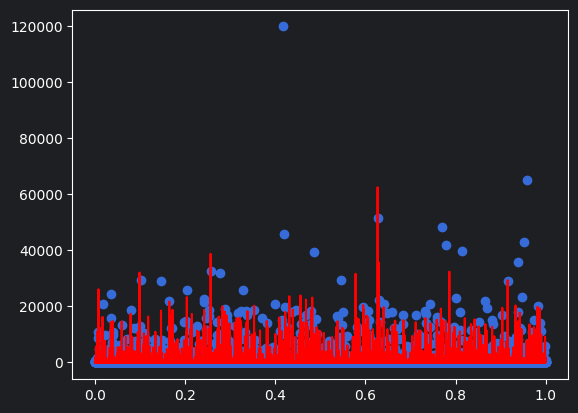

In [41]:
x = np.linspace(0, 1, num=len(predictions))

plt.scatter(x, y_test)
plt.plot(x, predictions, "r")
plt.show()